# XGBoost - Final Selected Model

Enter the hyperparameters selected from the individual validation trials below. This is the only notebook in this set intended to evaluate the held-out test split.

## 1. Environment Setup

Run this notebook from a clean Google Colab session or locally.


## 2. Package Installation


This cell checks whether the libraries required by the XGBoost workflow are installed and installs only the missing packages before the remaining audio-processing, analysis, plotting, and modelling steps run.

In [1]:
# Purpose: Checks whether the libraries required by the cache-based XGBoost workflow are installed.
import importlib.util
import subprocess
import sys

required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("joblib", "joblib"),
    ("xgboost", "xgboost"),
]

missing = [pip_name for import_name, pip_name in required_packages if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required packages are already installed.")


Required packages are already installed.


## 3. Imports


This cell imports the standard-library and third-party tools used by the XGBoost workflow and provides a print-based fallback when the richer notebook display function is unavailable.

In [2]:
# Purpose: Imports the standard-library and third-party tools used by the cache-based XGBoost workflow.
import json
import os
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

try:
    from IPython.display import display
except Exception:
    display = print


## 4. Configuration and Random Seeds


This cell fixes the available random seeds for reproducibility and defines the shared audio, MFCC, class, sampling, and XGBoost training settings used later in the notebook.

In [3]:
# Purpose: Fixes the random seed and label mapping used by the XGBoost trial.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

CLASS_NAMES = {0: "bona_fide", 1: "synthetic"}


## 5. Project and Output Paths


This cell defines and calls a portable helper that mounts Google Drive when Colab is available and otherwise continues without failing in a local environment.

In [4]:
# Purpose: Mounts Google Drive when this notebook is running in Google Colab.
def mount_drive_if_colab(mount_point="/content/drive"):
    try:
        from google.colab import drive
        drive.mount(mount_point)
        os.environ.setdefault(
            "INTRO_AI_PROJECT_ROOT",
            "/content/drive/MyDrive/Colab Notebooks/Education/INM701",
        )
        print("Google Colab detected. Google Drive mounted.")
    except Exception as exc:
        print("Google Colab Drive mount skipped. This is expected outside Colab.")
        print("Mount skip reason:", exc)

mount_drive_if_colab()
print("INTRO_AI_PROJECT_ROOT:", os.environ.get("INTRO_AI_PROJECT_ROOT", "not set"))


Mounted at /content/drive
Google Colab detected. Google Drive mounted.
INTRO_AI_PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/Education/INM701


This cell resolves the project folder, locates the existing shared SVM feature cache, and creates the XGBoost output folders. It does not scan raw audio.

In [5]:
# Purpose: Resolve paths for cache-based XGBoost trials.
def resolve_project_root():
    candidates = []
    explicit = os.environ.get("INTRO_AI_PROJECT_ROOT")
    if explicit:
        candidates.append(Path(explicit).expanduser())

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([
        Path(r"C:/Users/PC/Documents/GitHub/Intro-to-AI"),
        Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701"),
    ])

    for candidate in candidates:
        if (candidate / "outputs" / "outputs" / "svm" / "cache").exists():
            return candidate
        if (candidate / "outputs" / "svm" / "cache").exists():
            return candidate
    return candidates[0]


def first_existing_path(candidates):
    expanded = [Path(candidate).expanduser() for candidate in candidates]
    for candidate in expanded:
        if candidate.exists():
            return candidate
    return expanded[0]


PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = first_existing_path([
    PROJECT_ROOT / "outputs" / "outputs",
    PROJECT_ROOT / "outputs",
])

SVM_CACHE_DIR = first_existing_path([
    OUTPUTS_ROOT / "svm" / "cache",
    PROJECT_ROOT / "outputs" / "svm" / "cache",
])

OUTPUT_DIR = OUTPUTS_ROOT / "xgboost"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODELS_DIR = OUTPUT_DIR / "models"
TABLES_DIR = OUTPUT_DIR / "tables"

for directory in [OUTPUT_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Shared SVM cache:", SVM_CACHE_DIR)
print("XGBoost output directory:", OUTPUT_DIR)


Project root: /content/drive/MyDrive/Colab Notebooks/Education/INM701
Shared SVM cache: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/cache
XGBoost output directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/xgboost


## 6. Load Shared SVM Cache


This cell loads the already prepared 80-dimensional MFCC mean/std feature cache from the SVM pipeline. The test split is loaded only for final evaluation after the validation-selected model is fitted.

In [6]:
# Purpose: Load shared SVM MFCC cache, including the held-out test split for final evaluation only.
def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required cache file missing: {path}")
    return path

X_train_scaled = np.load(require_file(SVM_CACHE_DIR / "X_train.npy"), mmap_mode="r")
y_train = np.load(require_file(SVM_CACHE_DIR / "y_train.npy"))
X_validation_scaled = np.load(require_file(SVM_CACHE_DIR / "X_validation.npy"), mmap_mode="r")
y_validation = np.load(require_file(SVM_CACHE_DIR / "y_validation.npy"))
X_test_scaled = np.load(require_file(SVM_CACHE_DIR / "X_test.npy"), mmap_mode="r")
y_test = np.load(require_file(SVM_CACHE_DIR / "y_test.npy"))

train_meta = pd.read_csv(require_file(SVM_CACHE_DIR / "train_metadata.csv"))
validation_meta = pd.read_csv(require_file(SVM_CACHE_DIR / "validation_metadata.csv"))
test_meta = pd.read_csv(require_file(SVM_CACHE_DIR / "test_metadata.csv"))

with open(require_file(SVM_CACHE_DIR / "feature_config.json"), "r", encoding="utf-8") as f:
    feature_config = json.load(f)

scaler = joblib.load(require_file(SVM_CACHE_DIR / "svm_standard_scaler.joblib"))

for split_name, X_split, y_split in [
    ("train", X_train_scaled, y_train),
    ("validation", X_validation_scaled, y_validation),
    ("test", X_test_scaled, y_test),
]:
    if X_split.shape[1] != 80:
        raise RuntimeError(f"Expected 80 features for {split_name}, got {X_split.shape[1]}.")
    if len(X_split) != len(y_split):
        raise RuntimeError(f"Feature and label arrays are not aligned for {split_name}.")

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "bona_fide": [int((y_train == 0).sum()), int((y_validation == 0).sum()), int((y_test == 0).sum())],
    "synthetic": [int((y_train == 1).sum()), int((y_validation == 1).sum()), int((y_test == 1).sum())],
    "total": [len(y_train), len(y_validation), len(y_test)],
})
display(split_summary)

print("Loaded shared SVM feature cache:", SVM_CACHE_DIR)
print("Train:", X_train_scaled.shape, y_train.shape)
print("Validation:", X_validation_scaled.shape, y_validation.shape)
print("Test:", X_test_scaled.shape, y_test.shape)
print("Feature representation:", feature_config.get("representation", "not recorded"))
print("Raw audio rescanned: No")
print("MFCCs recomputed here: No")
print("Scaler refitted here: No")
print("Test split loaded here only for final evaluation, not model selection.")


,split,bona_fide,synthetic,total
0,train,2798,6262,9060
1,validation,599,1343,1942
2,test,600,1342,1942


Loaded shared SVM feature cache: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/cache
Train: (9060, 80) (9060,)
Validation: (1942, 80) (1942,)
Test: (1942, 80) (1942,)
Feature representation: aggregated MFCC mean+std (80 features), StandardScaler fitted on training only
Raw audio rescanned: No
MFCCs recomputed here: No
Scaler refitted here: No
Test split loaded here only for final evaluation, not model selection.


## 7. XGBoost Model Definition


This cell creates and prints an example XGBoost binary classifier with a specified tree count, depth, and learning rate, showing the estimator configuration used as a baseline.

In [7]:
# Purpose: Creates and prints an example XGBoost binary classifier with a specified tree count,
# depth, and learning rate, showing the estimator configuration used as a baseline.
from xgboost import XGBClassifier

# Construct a representative estimator so its architecture or configuration can be inspected.
example_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
)
print(example_model)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


## 8. Final Selected Hyperparameters and Validation Fit


Set `FINAL_PARAMS` from the completed individual trials. The model is fitted on the training split and checked on validation before the existing final test evaluation runs.

In [8]:
# Purpose: Fits one manually selected XGBoost configuration after the individual trials.
from xgboost import XGBClassifier

# Replace these defaults with the settings justified by your validation-trial results.
FINAL_PARAMS = dict(objective="binary:logistic", eval_metric="logloss", n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1)

best_variant = "final_selected"
best_model = XGBClassifier(**FINAL_PARAMS)
best_model.fit(X_train_scaled, y_train)

validation_probability = best_model.predict_proba(X_validation_scaled)[:, 1]
validation_pred = (validation_probability >= 0.5).astype(int)
validation_results_df = pd.DataFrame([{
    "model": 'XGBoost',
    "variant": best_variant,
    "accuracy": accuracy_score(y_validation, validation_pred),
    "precision": precision_score(y_validation, validation_pred, zero_division=0),
    "recall": recall_score(y_validation, validation_pred, zero_division=0),
    "f1": f1_score(y_validation, validation_pred, zero_division=0),
    **FINAL_PARAMS,
}])
display(validation_results_df)
print("Final selected parameters:", FINAL_PARAMS)


,model,variant,accuracy,precision,recall,f1,objective,eval_metric,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,random_state,n_jobs
0,XGBoost,final_selected,0.929454,0.961715,0.93522,0.948282,binary:logistic,logloss,200,4,0.05,0.9,0.9,42,-1


Final selected parameters: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'random_state': 42, 'n_jobs': -1}


## 9. Final Test Evaluation


This cell processes the untouched test split only after selecting the XGBoost variant, generates binary predictions, calculates the final accuracy, precision, recall, and F1 score, and displays the results.

In [9]:
# Purpose: Evaluates the already selected XGBoost model on the held-out test cache.
test_probability = best_model.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_probability >= 0.5).astype(int)

test_results_df = pd.DataFrame([{
    "selected_variant": best_variant,
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
}])

display(test_results_df)


,selected_variant,accuracy,precision,recall,f1
0,final_selected,0.934089,0.956391,0.947839,0.952096


## 10. Additional Subgroup / Multilingual Analysis


This cell joins the final predictions to the test metadata and calculates language-specific performance for subgroups containing at least five recordings, avoiding unstable summaries for very small groups.

In [10]:
# Purpose: Joins the final predictions to the test metadata and calculates language-specific
# performance for subgroups containing at least five recordings, avoiding unstable summaries for
# very small groups.
# Prepare language-level metrics using the final test predictions.
subgroup_rows = []
subgroup_df = test_meta.copy().reset_index(drop=True)
subgroup_df["y_true"] = y_test
subgroup_df["y_pred"] = test_pred

# Skip very small language groups and score those with enough test examples.
for language, group in subgroup_df.groupby("language"):
    if len(group) < 5:
        continue
    subgroup_rows.append({
        "language": language,
        "files": len(group),
        "accuracy": accuracy_score(group["y_true"], group["y_pred"]),
        "precision": precision_score(group["y_true"], group["y_pred"], zero_division=0),
        "recall": recall_score(group["y_true"], group["y_pred"], zero_division=0),
        "f1": f1_score(group["y_true"], group["y_pred"], zero_division=0),
    })

subgroup_results_df = pd.DataFrame(subgroup_rows)
if subgroup_results_df.empty:
    print("No language subgroup has at least 5 test files.")
else:
    display(subgroup_results_df.sort_values("f1", ascending=False))


,language,files,accuracy,precision,recall,f1
0,am,9,1.000000,1.000000,1.000000,1.000000
1,ar,65,1.000000,1.000000,1.000000,1.000000
2,bg,17,1.000000,1.000000,1.000000,1.000000
3,bn,20,1.000000,1.000000,1.000000,1.000000
12,he,18,1.000000,1.000000,1.000000,1.000000
9,fr,90,1.000000,1.000000,1.000000,1.000000
11,ha,12,1.000000,1.000000,1.000000,1.000000
10,ga,13,1.000000,1.000000,1.000000,1.000000
8,es,238,0.978992,1.000000,0.978992,0.989384
5,da,30,0.966667,1.000000,0.966667,0.983051


## 11. Confusion Matrix and Saved Outputs


This cell saves the XGBoost validation and test results, language metrics when available, confusion-matrix data and figures, preprocessing state, and selected model, then prints the main artifact paths.

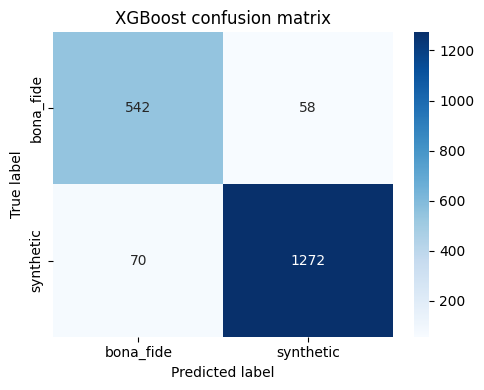

Saved validation results: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/xgboost/tables/xgboost_validation_experiments.csv
Saved test metrics: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/xgboost/metrics/xgboost_test_metrics.json
Saved confusion matrix: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/xgboost/metrics/xgboost_confusion_matrix.csv
Saved scaler: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/xgboost/models/xgboost_standard_scaler.joblib
Saved model: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/xgboost/models/xgboost_best_model.joblib


In [11]:
# Purpose: Saves the XGBoost validation and test results, language metrics when available,
# confusion-matrix data and figures, preprocessing state, and selected model, then prints the
# main artifact paths.
# Define consistent destinations for evaluation, plots, preprocessing state, and models.
validation_results_path = TABLES_DIR / "xgboost_validation_experiments.csv"
test_metrics_path = METRICS_DIR / "xgboost_test_metrics.json"
confusion_matrix_path = METRICS_DIR / "xgboost_confusion_matrix.csv"
subgroup_metrics_path = METRICS_DIR / "xgboost_language_subgroup_metrics.csv"
confusion_plot_path = FIGURES_DIR / "xgboost_confusion_matrix.png"
scaler_path = MODELS_DIR / "xgboost_standard_scaler.joblib"
model_path = MODELS_DIR / "xgboost_best_model.joblib"

validation_results_df.to_csv(validation_results_path, index=False)
with open(test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(test_results_df.iloc[0].to_dict(), f, indent=2)

# Build a labelled confusion matrix from the final test predictions.
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
pd.DataFrame(cm, index=[CLASS_NAMES[0], CLASS_NAMES[1]], columns=[CLASS_NAMES[0], CLASS_NAMES[1]]).to_csv(confusion_matrix_path)
if not subgroup_results_df.empty:
    subgroup_results_df.to_csv(subgroup_metrics_path, index=False)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]], yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("XGBoost confusion matrix")
plt.tight_layout()
plt.savefig(confusion_plot_path, dpi=300, bbox_inches="tight")
plt.show()

joblib.dump(scaler, scaler_path)
joblib.dump(best_model, model_path)


print("Saved validation results:", validation_results_path)
print("Saved test metrics:", test_metrics_path)
print("Saved confusion matrix:", confusion_matrix_path)
print("Saved scaler:", scaler_path)
print("Saved model:", model_path)


## 12. Reproducibility Checks


This cell displays a compact reproducibility record for the XGBoost workflow, including the stratified split, train-only preprocessing, test-set isolation, label mapping, dependency design, and random seed.

In [12]:
# Purpose: Displays a compact reproducibility record for the cache-based XGBoost workflow.
checks = {
    "self_contained": True,
    "external_helper_file_required": False,
    "custom_helper_imports": False,
    "feature_source": "shared SVM 80-D MFCC mean/std cache",
    "raw_audio_rescanned_here": False,
    "mfccs_recomputed_here": False,
    "scaler_refitted_here": False,
    "split_source": "saved train/validation/test arrays from SVM cache",
    "test_used_for_model_selection": False,
    "label_mapping": CLASS_NAMES,
    "random_state": RANDOM_STATE,
}

display(pd.DataFrame(list(checks.items()), columns=["check", "value"]))


,check,value
0,self_contained,True
1,external_helper_file_required,False
2,custom_helper_imports,False
3,feature_source,shared SVM 80-D MFCC mean/std cache
4,raw_audio_rescanned_here,False
5,mfccs_recomputed_here,False
6,scaler_refitted_here,False
7,split_source,saved train/validation/test arrays from SVM cache
8,test_used_for_model_selection,False
9,label_mapping,"{0: 'bona_fide', 1: 'synthetic'}"
